In [1]:
!pip install anndata==0.8.0

In [3]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.pyplot as plt

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
sns = [
       'SoupX/',
      ]
org = 'Killi'

In [6]:
for sample_name in sns:
    dat = sc.read_h5ad('SoupX/' + org + '/' + sample_name)
    print(dat.X[:,1])
    
    sam=SAM(dat)
    sam.preprocess_data() #log transforms and filters the data
    sam.run() #run with default parameters
    
    sam.clustering(param = 1)
    print(sam.adata.obs['leiden_clusters'].nunique())
    
    dat_dense = dat.X.todense()
    df = pd.DataFrame(data = dat_dense, columns=dat.var_names, index = dat.obs_names).T
    df.to_csv('SoupX/'+ org + '/' + sample_name + '_filtered.csv')
    sam.adata.obs['leiden_clusters'].to_csv('SoupX/' + org + '/' + sample_name +'_leiden_clusters.csv')

  (132, 0)	1.0
  (242, 0)	1.0
  (333, 0)	1.0
  (382, 0)	1.0
  (444, 0)	1.0
  (597, 0)	1.0
  (669, 0)	1.0
  (701, 0)	1.0
  (703, 0)	1.0
  (706, 0)	1.0
  (919, 0)	1.0
  (1006, 0)	1.0
  (1175, 0)	1.0
  (1226, 0)	1.0
  (1243, 0)	1.0
  (1269, 0)	1.0
  (1302, 0)	2.0
  (1374, 0)	1.0
  (1598, 0)	1.0
  (1637, 0)	1.0
  (1664, 0)	1.0
  (1881, 0)	1.0
  (1938, 0)	1.0
  (1944, 0)	1.0
  (1999, 0)	1.0
  :	:
  (17061, 0)	1.0
  (17101, 0)	1.0
  (17228, 0)	1.0
  (17340, 0)	1.0
  (17434, 0)	1.0
  (17511, 0)	1.0
  (17656, 0)	1.0
  (17761, 0)	1.0
  (17964, 0)	1.0
  (18084, 0)	1.0
  (18117, 0)	1.0
  (18136, 0)	1.0
  (18189, 0)	1.0
  (18402, 0)	1.0
  (18483, 0)	1.0
  (18494, 0)	1.0
  (18544, 0)	1.0
  (18554, 0)	1.0
  (18628, 0)	1.0
  (18745, 0)	1.0
  (18860, 0)	1.0
  (19122, 0)	1.0
  (19228, 0)	1.0
  (19303, 0)	1.0
  (19364, 0)	1.0
RUNNING SAM
Iteration: 0, Convergence: 1.0
Iteration: 1, Convergence: 0.8415494466782533
Iteration: 2, Convergence: 0.013217778495699032
Computing the UMAP embedding...
Elapsed tim

In [8]:
dat = pd.read_csv('SoupX/MV/processedrun_Run15_sample1_MV_soupcorr.csv')

In [ ]:
dat

In [495]:
dat = sc.read_h5ad('SoupX/MO/preprocessed_' + sample_name + '_MO_soupx.h5ad')

In [496]:
dat.X

<9959x18265 sparse matrix of type '<class 'numpy.float32'>'
	with 32121890 stored elements in Compressed Sparse Row format>

In [497]:
print(dat.X[:,1])

  (2, 0)	4.0
  (5, 0)	2.0
  (6, 0)	1.0
  (8, 0)	1.0
  (11, 0)	2.0
  (14, 0)	1.0
  (19, 0)	2.0
  (21, 0)	1.0
  (26, 0)	1.0
  (28, 0)	1.0
  (30, 0)	1.0
  (32, 0)	3.0
  (33, 0)	1.0
  (34, 0)	1.0
  (36, 0)	1.0
  (39, 0)	1.0
  (40, 0)	1.0
  (41, 0)	1.0
  (42, 0)	1.0
  (43, 0)	1.0
  (44, 0)	1.0
  (45, 0)	1.0
  (48, 0)	1.0
  (49, 0)	1.0
  (56, 0)	4.0
  :	:
  (9919, 0)	1.0
  (9920, 0)	1.0
  (9922, 0)	1.0
  (9923, 0)	1.0
  (9924, 0)	2.0
  (9925, 0)	3.0
  (9927, 0)	1.0
  (9931, 0)	1.0
  (9932, 0)	2.0
  (9937, 0)	1.0
  (9940, 0)	1.0
  (9943, 0)	3.0
  (9944, 0)	3.0
  (9945, 0)	3.0
  (9946, 0)	4.0
  (9947, 0)	1.0
  (9948, 0)	1.0
  (9949, 0)	2.0
  (9950, 0)	2.0
  (9952, 0)	1.0
  (9953, 0)	1.0
  (9954, 0)	5.0
  (9955, 0)	2.0
  (9956, 0)	1.0
  (9957, 0)	1.0


In [498]:
sam=SAM(dat)
sam.preprocess_data() #log transforms and filters the data
sam.run() #run with default parameters

RUNNING SAM
Iteration: 0, Convergence: 1.0
Iteration: 1, Convergence: 0.711196613589565
Iteration: 2, Convergence: 0.018700260571283545
Computing the UMAP embedding...
Elapsed time: 81.25974488258362 seconds


In [499]:
sam.clustering(param = 3)

In [500]:
sam.adata.obs['leiden_clusters'].nunique()

68

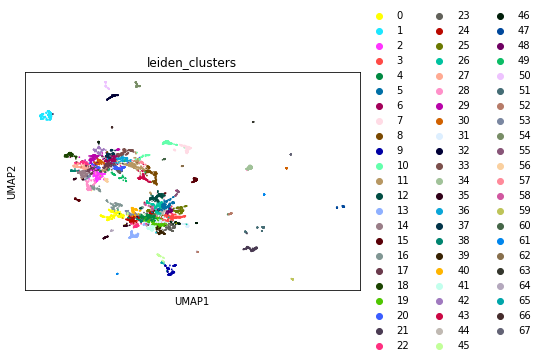

In [501]:
sc.pl.umap(sam.adata, color = 'leiden_clusters')

In [436]:
dat_dense = dat.X.todense()

In [333]:
df = pd.DataFrame(data = dat_dense, columns=dat.var_names, index = dat.obs_names).T

In [334]:
df.to_csv('SoupX/Run12_sample11_filtered.csv')

In [502]:
sam.adata.obs['leiden_clusters'].to_csv('SoupX/MO/' + sample_name +'_leiden_clusters.csv')